In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('data.csv').to_numpy()

In [3]:
data = (data - data.mean(axis=1).reshape(-1, 1)) / data.std(axis=1).reshape(-1, 1)

In [4]:
train_length = round(len(data) * 0.8)

In [5]:
train_data = torch.tensor(data[:train_length], dtype=torch.float32)
test_data = torch.tensor(data[train_length:], dtype=torch.float32)
all_data = torch.tensor(data, dtype=torch.float32)

In [6]:
train_loader = DataLoader(TensorDataset(train_data), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(test_data), batch_size=16, shuffle=False)
all_loader = DataLoader(TensorDataset(all_data), batch_size=16, shuffle=True)

In [7]:
# Сверточный автокодировщик
class ConvAutoencoder(nn.Module):
    def __init__(self, bottleneck_size):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 92, bottleneck_size)
            
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 64 * 92),
            nn.Unflatten(1, (64, 92)),
            nn.ConvTranspose1d(64, 32, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 8, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(8, 1, kernel_size=3, stride=2, output_padding=1),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
model = ConvAutoencoder(bottleneck_size=48).to(device)

In [10]:
k = 0
for param in model.parameters():
    if param.requires_grad:
        k += torch.prod(torch.tensor(param.size()))
print(f'Model has {k} trainable parameters')

Model has 587537 trainable parameters


In [11]:
optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

In [12]:
all_train_losses = []
train_losses = []
test_losses = []

In [13]:
epochs = 25

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in train_loader:
        batch = batch[0].unsqueeze(1).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        all_train_losses.append(loss.item())
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')
    train_losses.append(avg_loss)
    
    model.eval()
    avg_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch[0].unsqueeze(1).to(device)
            preds = model(batch)
            loss = criterion(preds, batch)
            
            avg_test_loss += loss.item()
    avg_test_loss /= len(test_loader)
    test_losses.append(avg_test_loss)
    print(f'Test Loss: {avg_test_loss:.4f}')

Epoch 1, Loss: 1.0143
Test Loss: 0.8876
Epoch 2, Loss: 0.8170
Test Loss: 0.7616
Epoch 3, Loss: 0.7334
Test Loss: 0.7036
Epoch 4, Loss: 0.6823
Test Loss: 0.6593
Epoch 5, Loss: 0.6386
Test Loss: 0.6181
Epoch 6, Loss: 0.5958
Test Loss: 0.5771
Epoch 7, Loss: 0.5560
Test Loss: 0.5397
Epoch 8, Loss: 0.5183
Test Loss: 0.5045
Epoch 9, Loss: 0.4854
Test Loss: 0.4735
Epoch 10, Loss: 0.4514
Test Loss: 0.4414
Epoch 11, Loss: 0.4156
Test Loss: 0.4056
Epoch 12, Loss: 0.3773
Test Loss: 0.3706
Epoch 13, Loss: 0.3491
Test Loss: 0.3544
Epoch 14, Loss: 0.3384
Test Loss: 0.3479
Epoch 15, Loss: 0.3315
Test Loss: 0.3437
Epoch 16, Loss: 0.3254
Test Loss: 0.3409
Epoch 17, Loss: 0.3223
Test Loss: 0.3392
Epoch 18, Loss: 0.3199
Test Loss: 0.3369
Epoch 19, Loss: 0.3165
Test Loss: 0.3352
Epoch 20, Loss: 0.3155
Test Loss: 0.3343
Epoch 21, Loss: 0.3121
Test Loss: 0.3324
Epoch 22, Loss: 0.3102
Test Loss: 0.3317
Epoch 23, Loss: 0.3069
Test Loss: 0.3309
Epoch 24, Loss: 0.3071
Test Loss: 0.3302
Epoch 25, Loss: 0.3046
Te

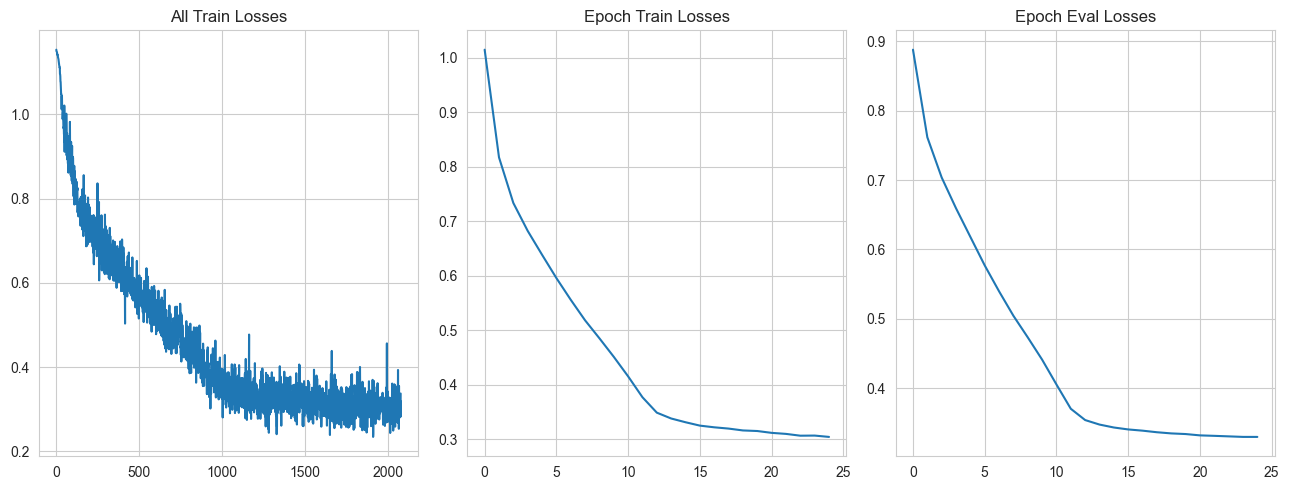

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].plot(all_train_losses)
axes[0].set_title('All Train Losses')
axes[1].plot(train_losses)
axes[1].set_title('Epoch Train Losses')
axes[2].plot(test_losses)
axes[2].set_title('Epoch Eval Losses')
plt.tight_layout()
plt.show()

In [15]:
model = ConvAutoencoder(bottleneck_size=48).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)

epochs = 25

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in all_loader:
        batch = batch[0].unsqueeze(1).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch 1, Loss: 0.9114
Epoch 2, Loss: 0.6662
Epoch 3, Loss: 0.6031
Epoch 4, Loss: 0.5661
Epoch 5, Loss: 0.5483
Epoch 6, Loss: 0.5285
Epoch 7, Loss: 0.4969
Epoch 8, Loss: 0.4633
Epoch 9, Loss: 0.4396
Epoch 10, Loss: 0.4233
Epoch 11, Loss: 0.4130
Epoch 12, Loss: 0.4058
Epoch 13, Loss: 0.4005
Epoch 14, Loss: 0.3967
Epoch 15, Loss: 0.3936
Epoch 16, Loss: 0.3907
Epoch 17, Loss: 0.3886
Epoch 18, Loss: 0.3865
Epoch 19, Loss: 0.3845
Epoch 20, Loss: 0.3825
Epoch 21, Loss: 0.3809
Epoch 22, Loss: 0.3792
Epoch 23, Loss: 0.3771
Epoch 24, Loss: 0.3753
Epoch 25, Loss: 0.3736


In [16]:
errors = []
encoded = []
reconstructed = []
with torch.no_grad():
    for sample in all_data:
        inputs = sample.view(1, 1, -1).to(device)
        res = model(inputs).cpu().detach().flatten()
        reconstruction_error = criterion(res, sample)
        errors.append(reconstruction_error.numpy())
        
        features = model.encoder(inputs).view(-1)
        encoded.append(features.cpu().detach().numpy())
        
        reconstructed.append(res.view(-1).cpu().detach().numpy())

errors = np.array(errors)
encoded = np.array(encoded)
reconstructed = np.array(reconstructed)

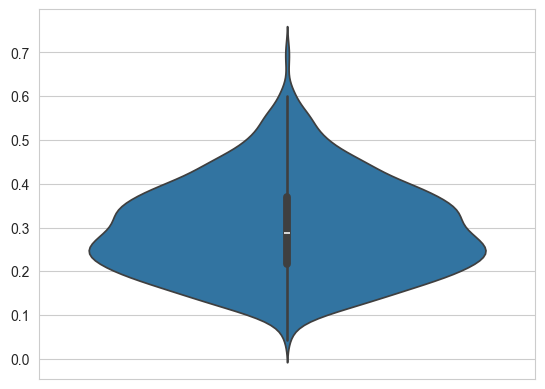

In [17]:
sns.violinplot(errors)
plt.show()

In [18]:
np.quantile(errors, 0.99)

0.5735884451866148

In [19]:
np.column_stack((np.argsort(-errors), -np.sort(-errors)))

array([[1.22500000e+03, 7.10185289e-01],
       [9.08000000e+02, 7.00623870e-01],
       [2.80000000e+01, 6.89608693e-01],
       ...,
       [1.09000000e+02, 6.11304976e-02],
       [1.10200000e+03, 5.60464188e-02],
       [2.23000000e+02, 4.23472300e-02]])

In [21]:
def plot_sample(sample):
    _, ax = plt.subplots(figsize=(20, 5))
    ax.plot(data[sample], label='True Row')
    pred_row = reconstructed[sample]
    ax.plot(pred_row, label='Predicted Row')
    mse = np.linalg.norm(data[sample] - pred_row) ** 2 / len(data[sample])
    ax.set_title(f'Model Prediction VS True Row, MSE: {mse.round(2)}, Sample: {sample}')
    plt.legend()
    plt.show()

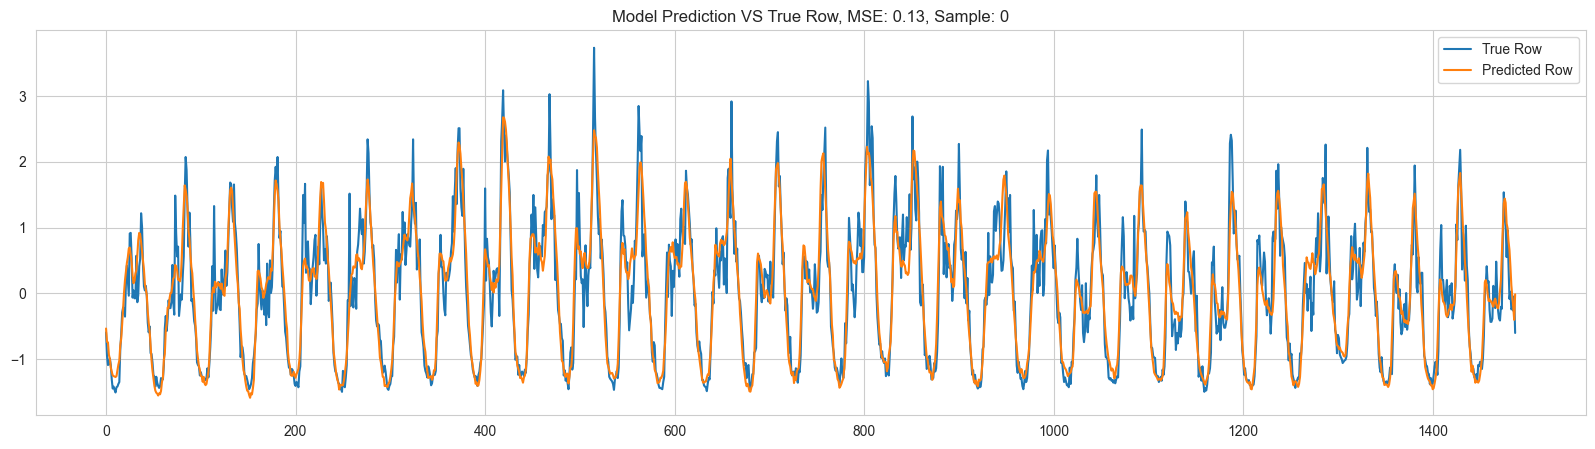

In [22]:
plot_sample(0)

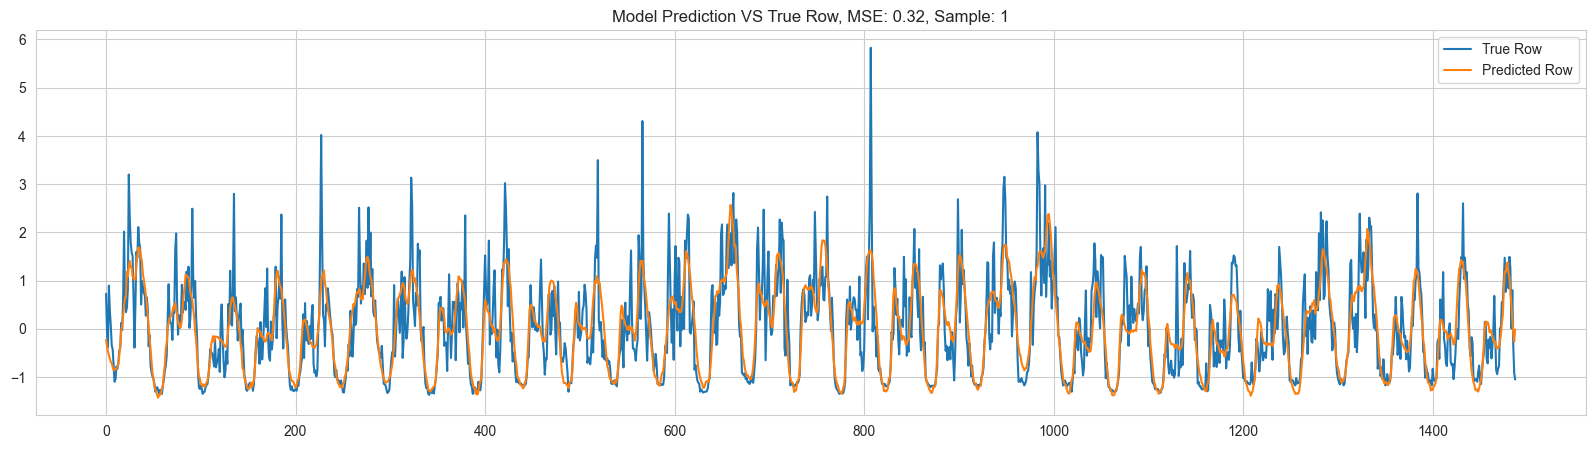

In [23]:
plot_sample(1)

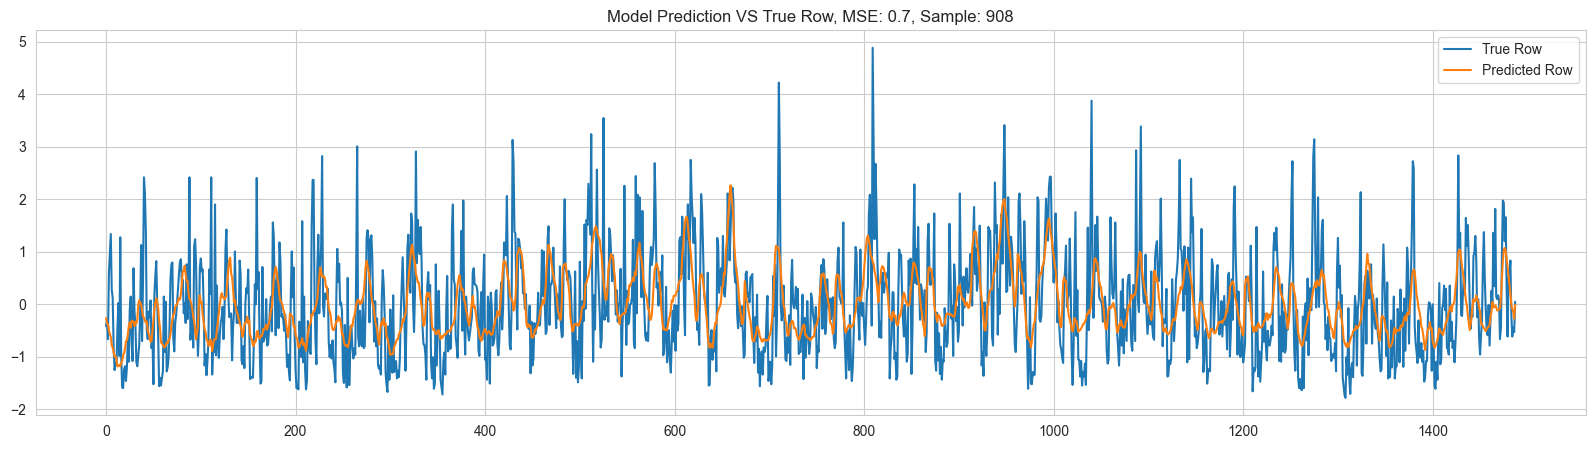

In [24]:
plot_sample(908)

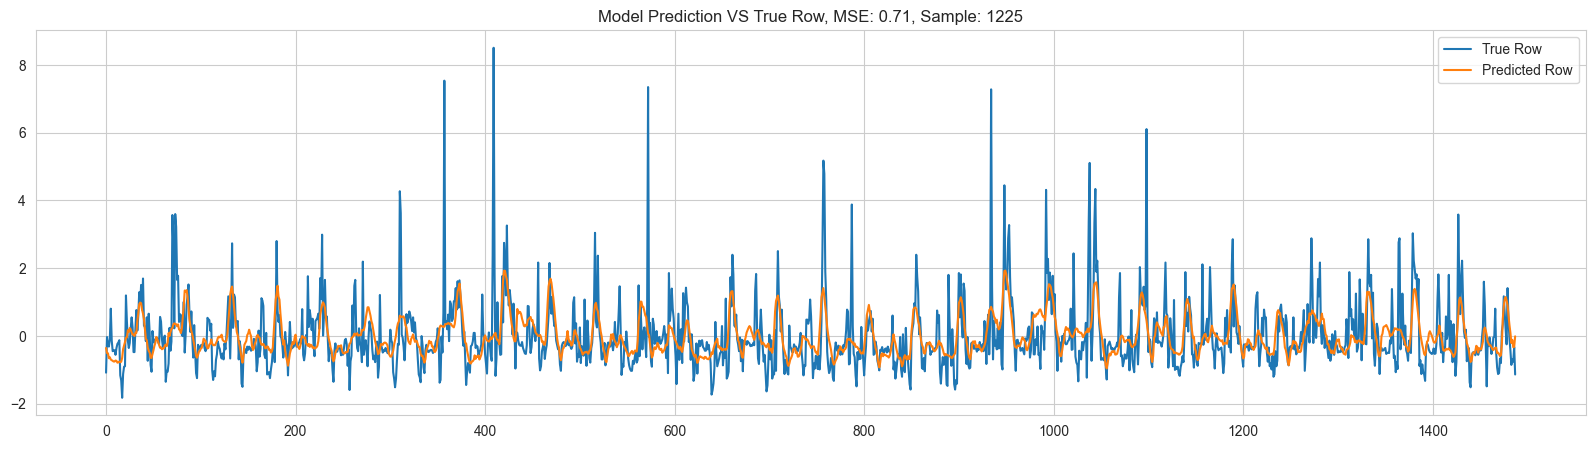

In [25]:
plot_sample(1225)

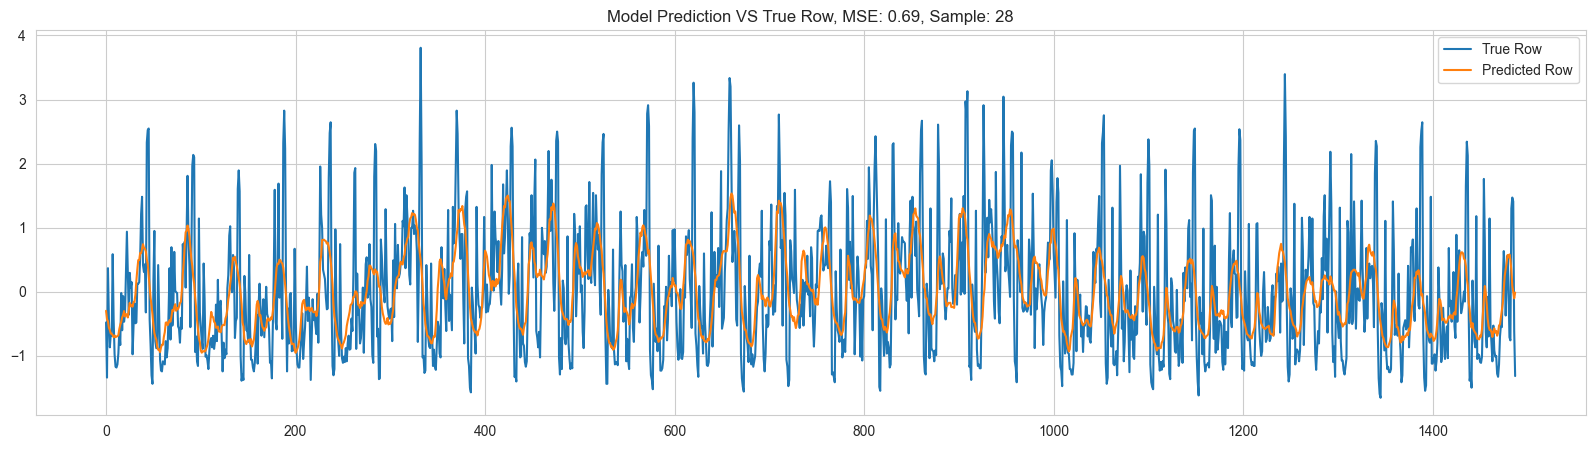

In [26]:
plot_sample(28)

In [27]:
encoded

array([[ -6.6963205 ,  -5.0330315 ,   6.1322937 , ...,   5.6498966 ,
          0.9048723 ,  -6.5259814 ],
       [ -7.113227  ,  -2.079349  ,   1.8163843 , ...,   9.74504   ,
          1.2351316 ,  -7.0059514 ],
       [ -4.0798254 ,  -1.0571439 ,   3.7208648 , ...,   2.137967  ,
          3.3814719 ,  -6.570127  ],
       ...,
       [ -0.6482883 , -12.228262  ,   0.8352405 , ...,   9.823028  ,
          0.3936289 ,  -8.391049  ],
       [  1.5670506 ,  -4.532434  ,   4.463272  , ...,   5.968559  ,
          0.690649  ,  -6.5174212 ],
       [ -5.5280666 ,  -7.541479  ,   1.1376389 , ...,   1.4487967 ,
          4.0643234 ,  -0.97305506]], dtype=float32)

In [28]:
encoded_norm = (encoded - encoded.mean(axis=0)) / encoded.std(axis=0)

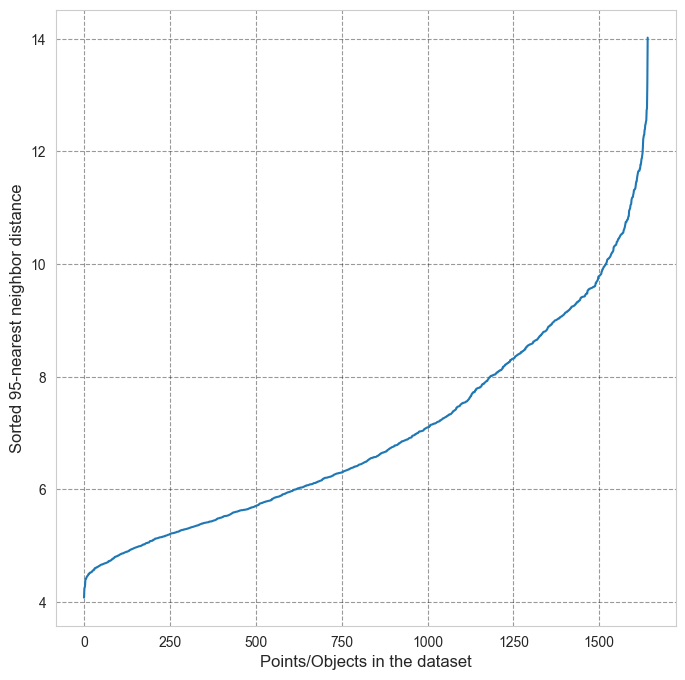

In [29]:
from sklearn.neighbors import NearestNeighbors


def get_kdist_plot(X=None, k=None, radius_nbrs=1.0):

    nbrs = NearestNeighbors(n_neighbors=k, radius=radius_nbrs).fit(X)

    # For each point, compute distances to its k-nearest neighbors
    distances, indices = nbrs.kneighbors(X) 
                                       
    distances = np.sort(distances, axis=0)
    distances = distances[:, k-1]

    # Plot the sorted K-nearest neighbor distance for each point in the dataset
    plt.figure(figsize=(8,8))
    plt.plot(distances)
    plt.xlabel('Points/Objects in the dataset', fontsize=12)
    plt.ylabel('Sorted {}-nearest neighbor distance'.format(k), fontsize=12)
    plt.grid(True, linestyle="--", color='black', alpha=0.4)
    plt.show()
    plt.close()


k = 2 * encoded_norm.shape[-1] - 1 # k=2*{dim(dataset)} - 1
get_kdist_plot(X=encoded_norm, k=k)

In [50]:
from sklearn.cluster import DBSCAN

# Создаем объект DBSCAN
dbscan = DBSCAN(eps=10.42, min_samples=20)

# Проводим кластеризацию данных
clusters = dbscan.fit_predict(encoded_norm)

# Ищем объекты, отнесенные к кластеру -1 (это аномалии)
anomalies_indices = np.where(clusters == -1)[0]
anomalies_indices

array([  56,  528,  584,  647,  704,  834,  950, 1014, 1119, 1486],
      dtype=int64)

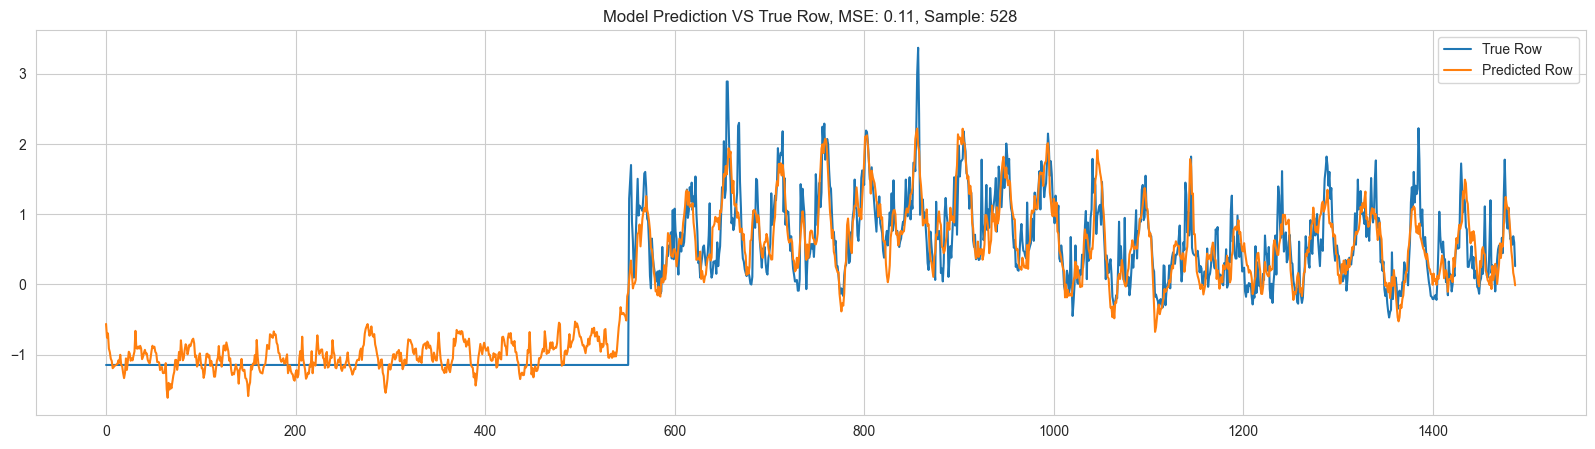

In [170]:
plot_sample(528)

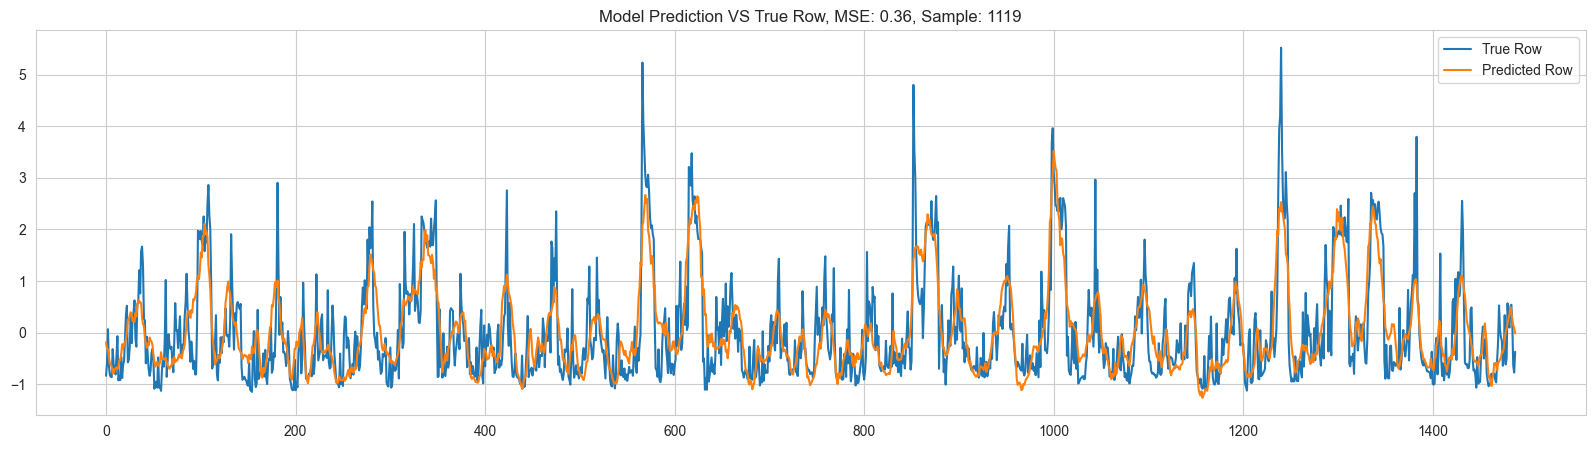

In [41]:
plot_sample(1119)

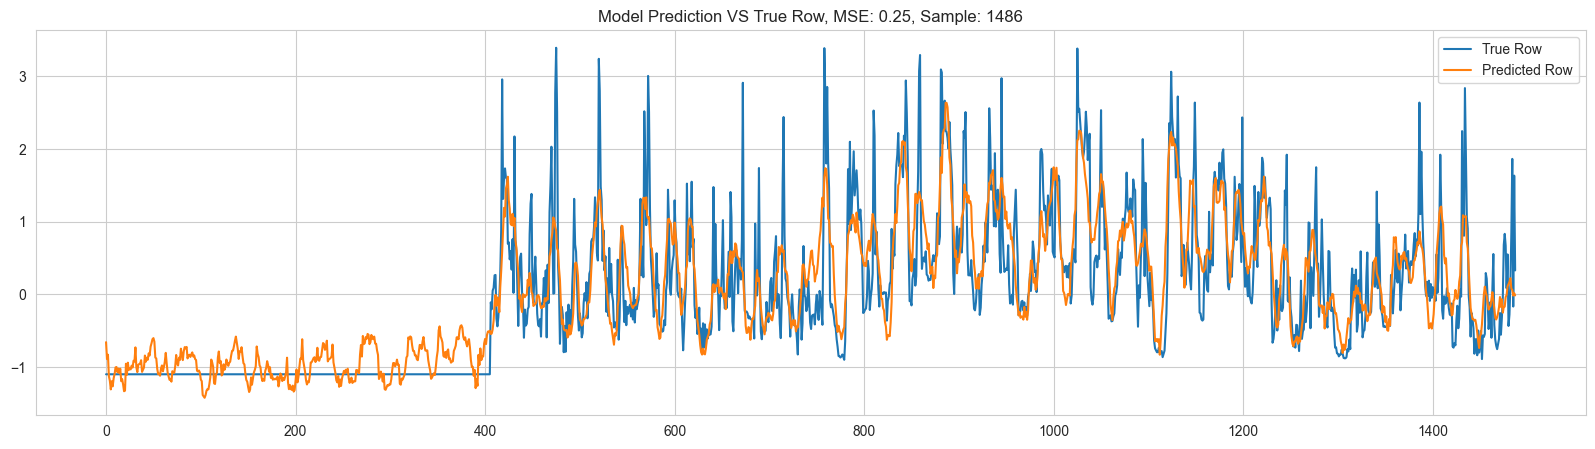

In [42]:
plot_sample(1486)

In [52]:
encoded.shape

(1642, 48)

In [56]:
empiric_bandwidth = (4 / 3 / len(encoded)) ** (1 / 5)
empiric_bandwidth

0.2409423360767331

In [176]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel='gaussian', bandwidth=2.5)
kde.fit(encoded_norm)

KernelDensity(bandwidth=2.5)

In [177]:
kde_scores = kde.score_samples(encoded_norm)

<Axes: >

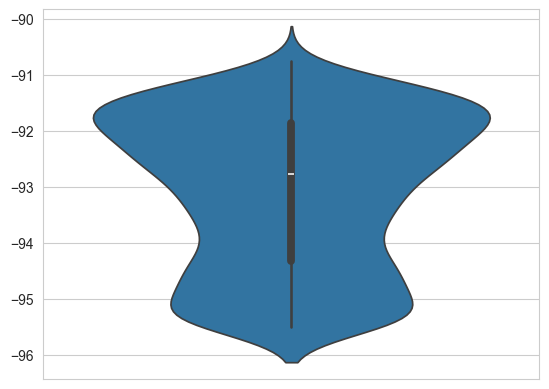

In [178]:
sns.violinplot(kde_scores)

In [179]:
np.vstack((np.sort(kde_scores), np.argsort(kde_scores))).T

array([[ -95.49366657, 1486.        ],
       [ -95.49303429, 1119.        ],
       [ -95.49291693,  950.        ],
       ...,
       [ -90.85771661, 1506.        ],
       [ -90.85110362,  438.        ],
       [ -90.7598191 , 1505.        ]])

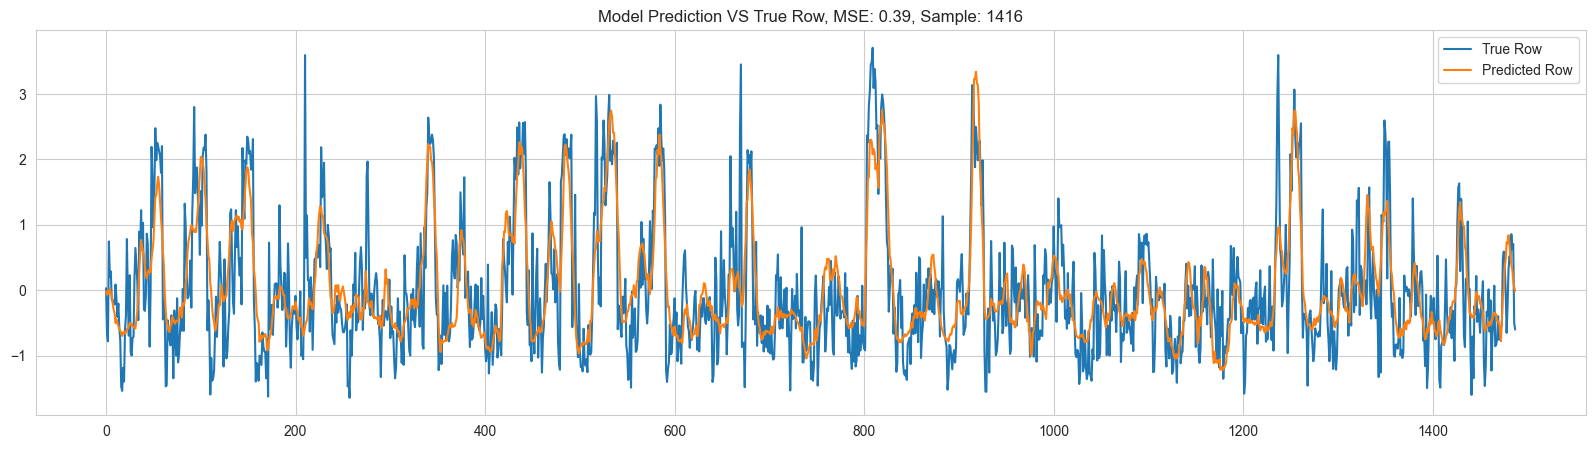

In [142]:
plot_sample(1416)

In [143]:
data[0]

array([-0.59020536, -0.94778906, -1.08684939, ..., -0.2624203 ,
       -0.04389692, -0.60013824])

In [159]:
def plot_data(sample):
    fix, ax = plt.subplots(figsize=(9, 4))
    ax.plot(data[sample], label=f'Sample {sample}')
    ax.legend()
    fig.tight_layout()

In [ ]:
1486.0
647.0
1119.0
1416.0
950.0
704.0
1018.0
528.0
720.0
1443.0



In [185]:
encoded_norm.shape

(1642, 48)

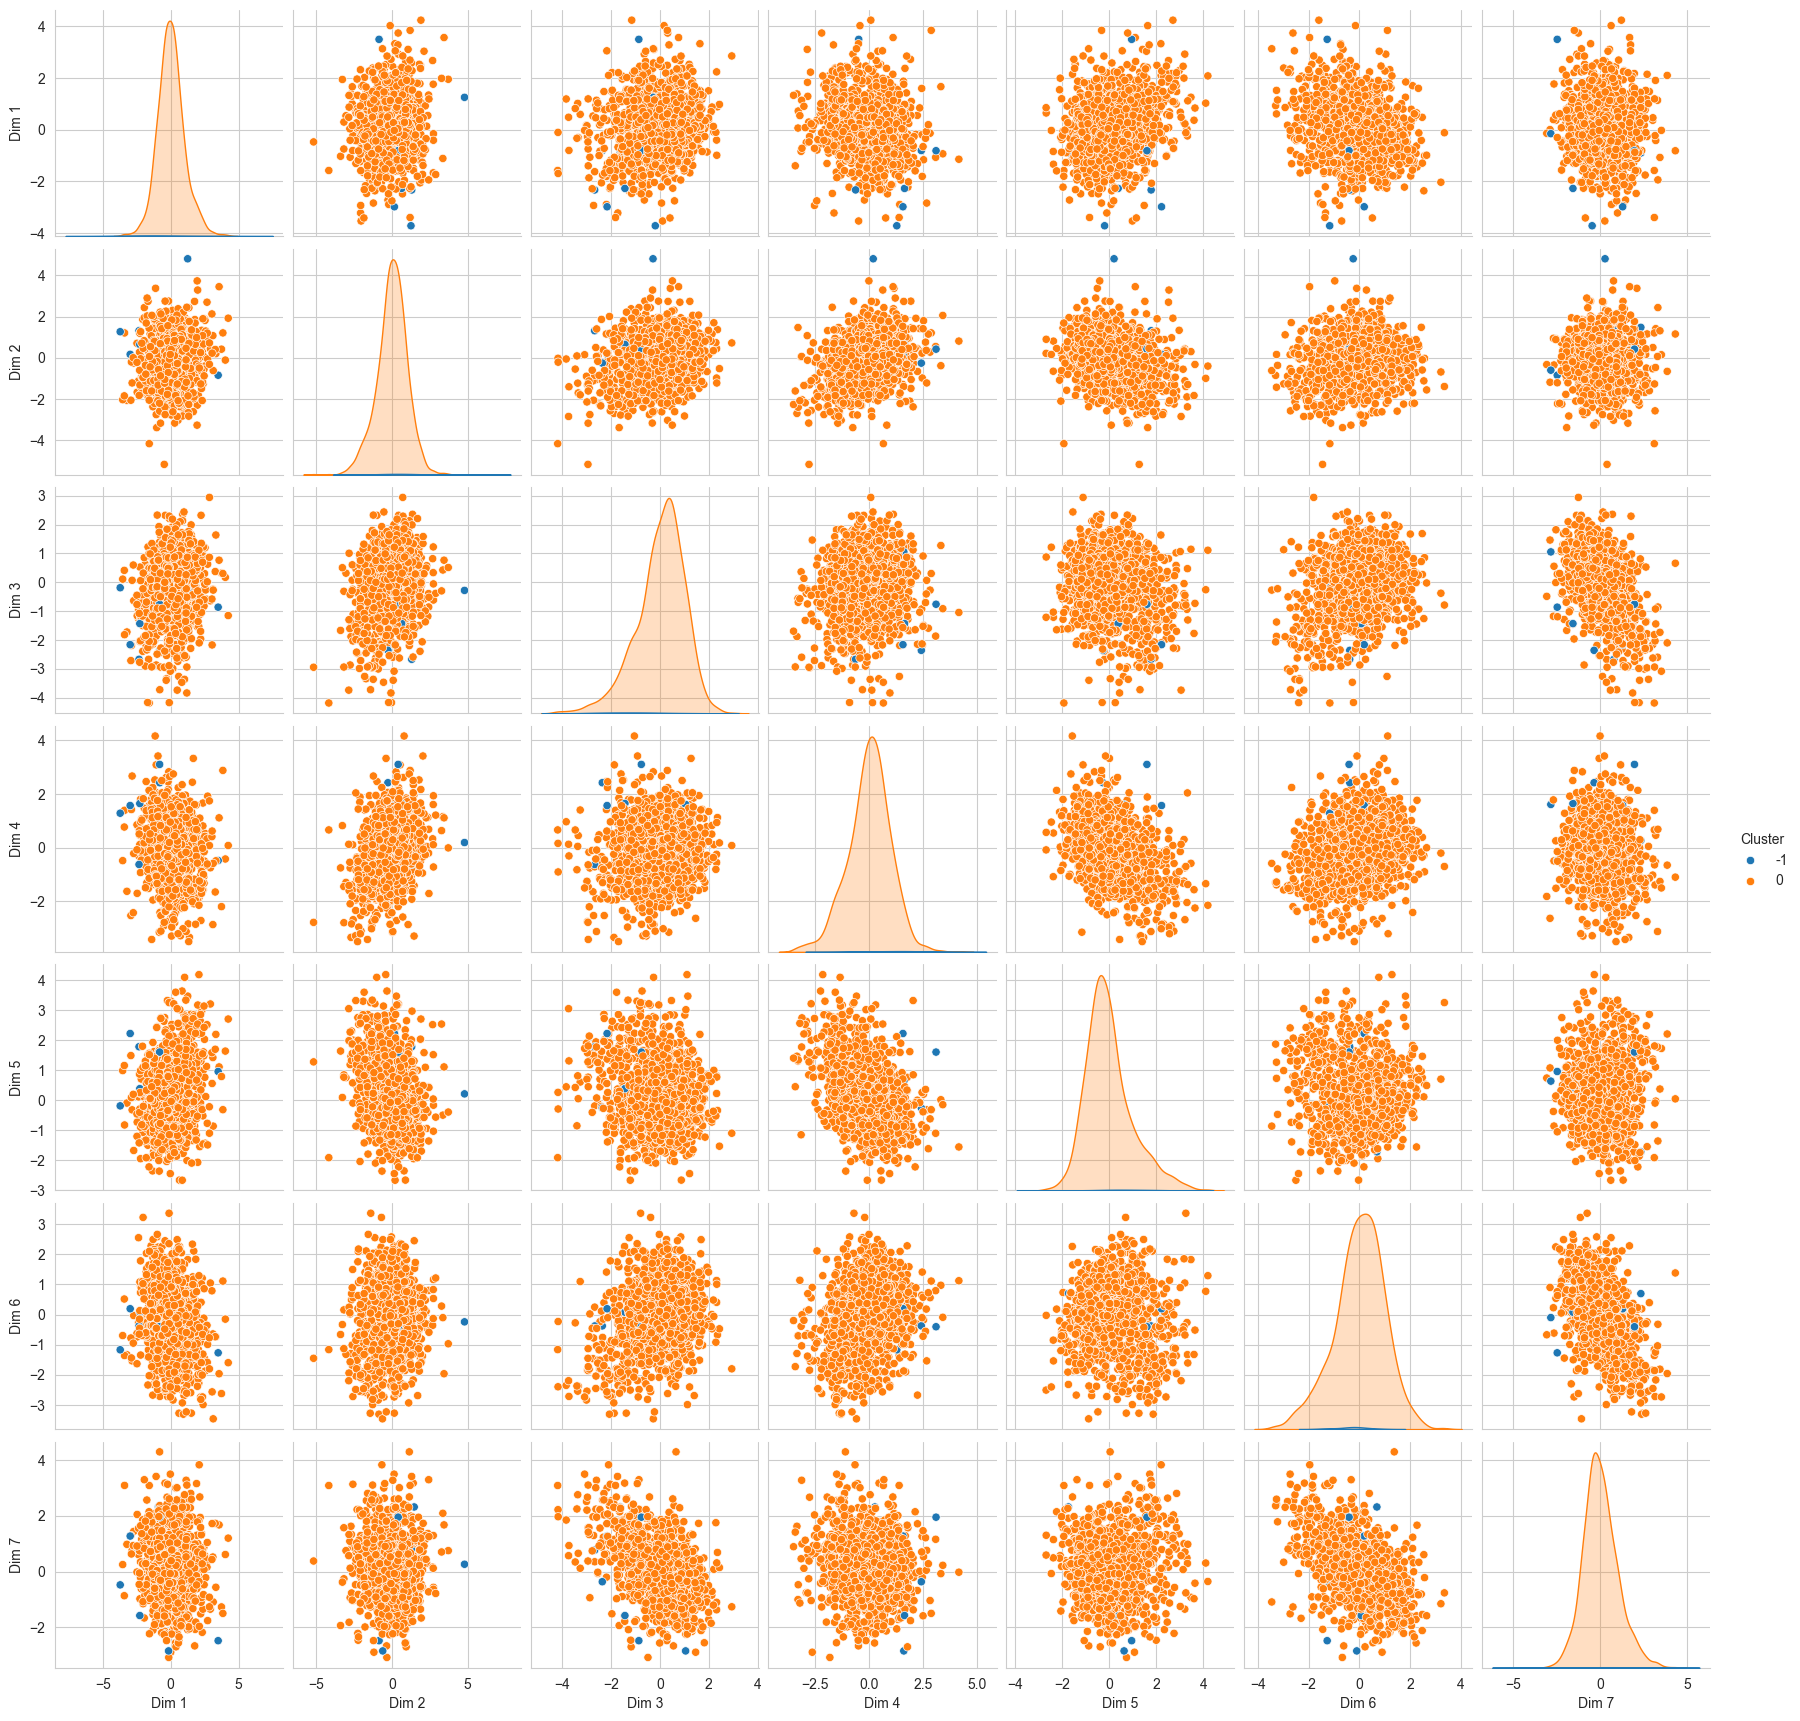

In [199]:
# Преобразуем массив данных в DataFrame
n = 7
df = pd.DataFrame(encoded_norm[:, :n], columns=[f'Dim {i + 1}' for i in range(n)])

# Добавляем столбец 'Cluster', содержащий метки кластеров
df['Cluster'] = clusters

# Создаем pairplot, выделяя разные кластеры цветом
sns.pairplot(df, hue='Cluster', palette='tab10')
plt.show()

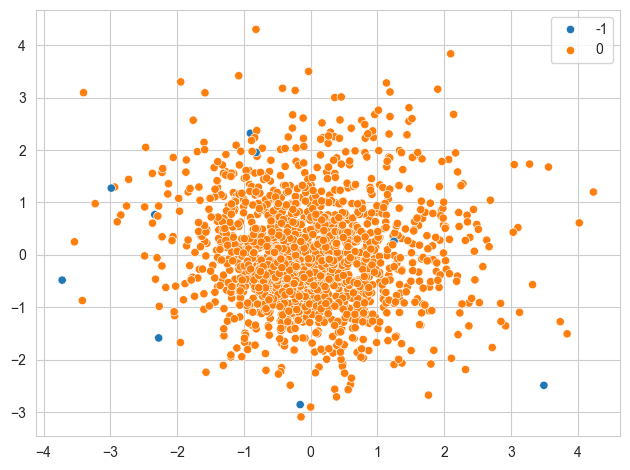

In [201]:
sns.scatterplot(x=encoded_norm[:, 0], y=encoded_norm[:, 6], hue=clusters, palette='tab10')
plt.tight_layout()
plt.show()

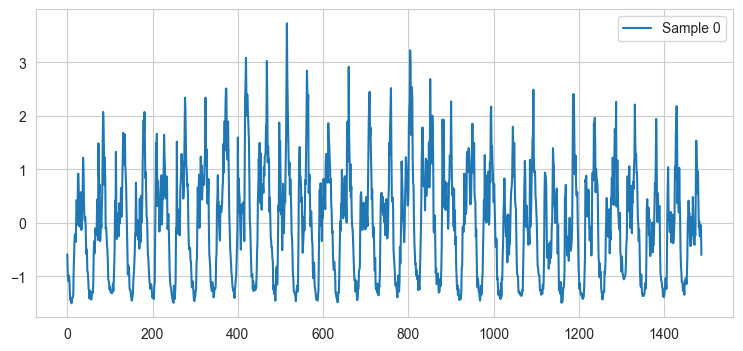

In [202]:
plot_data(0)

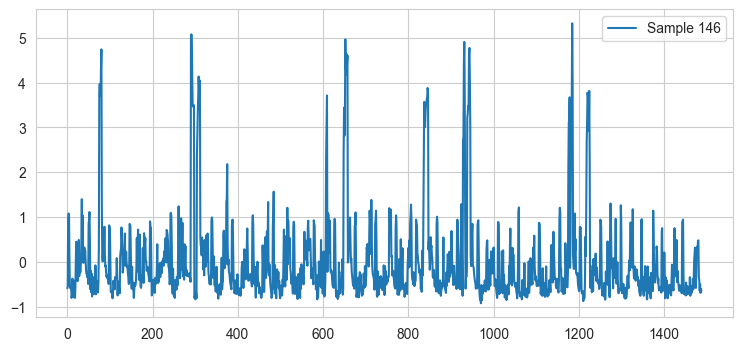

In [220]:
plot_data(146)

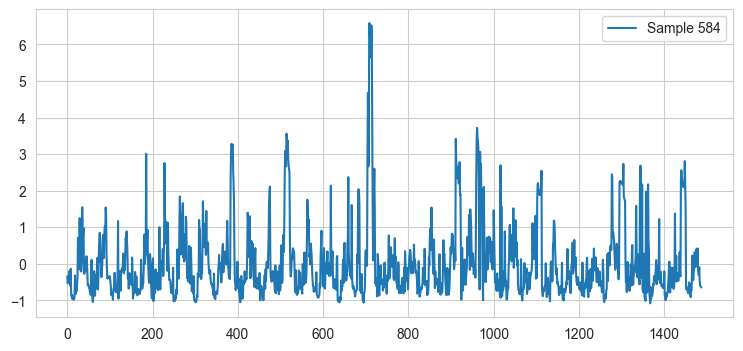

In [221]:
plot_data(584)

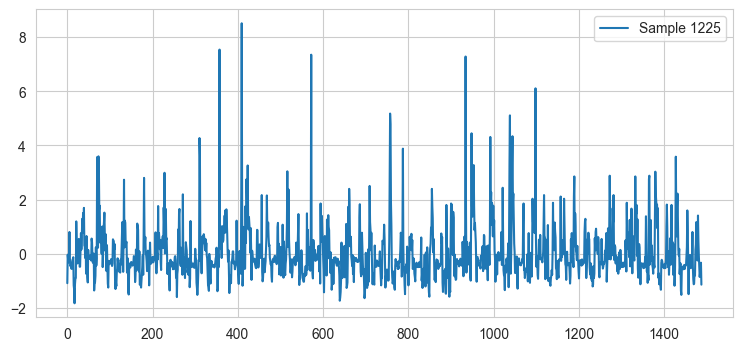

In [222]:
plot_data(1225)

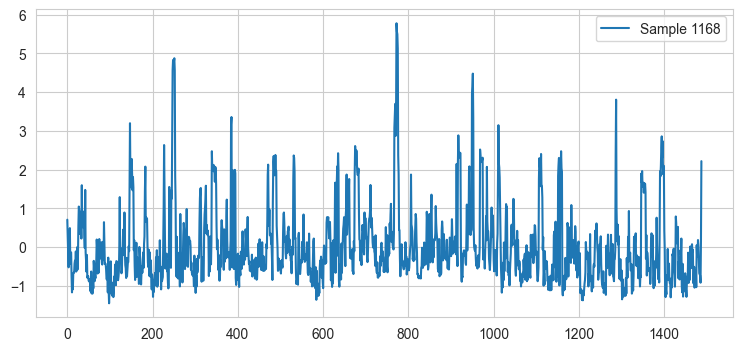

In [223]:
plot_data(1168)

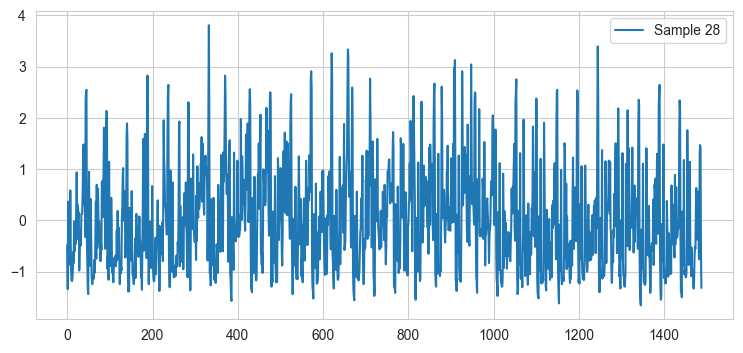

In [224]:
plot_data(28)

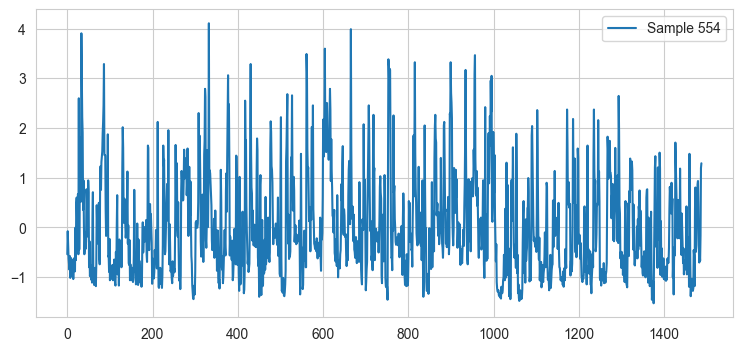

In [225]:
plot_data(554)

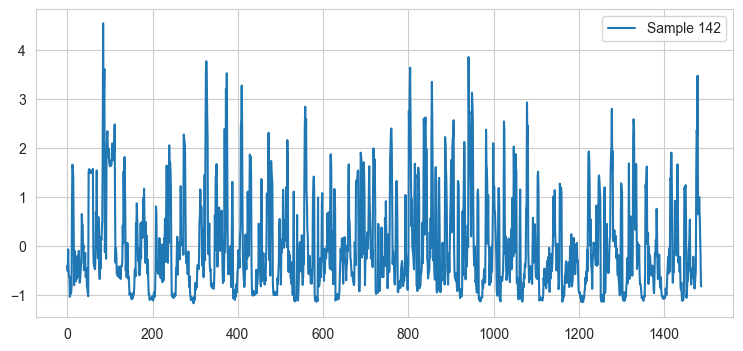

In [226]:
plot_data(142)

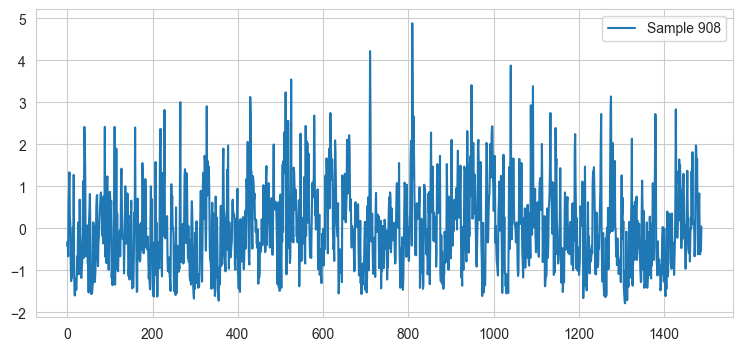

In [227]:
plot_data(908)

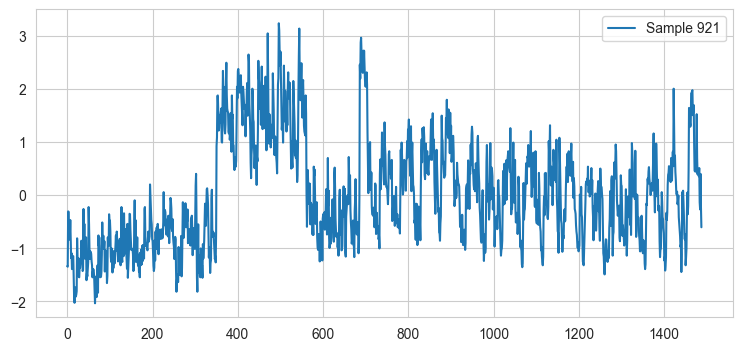

In [228]:
plot_data(921)

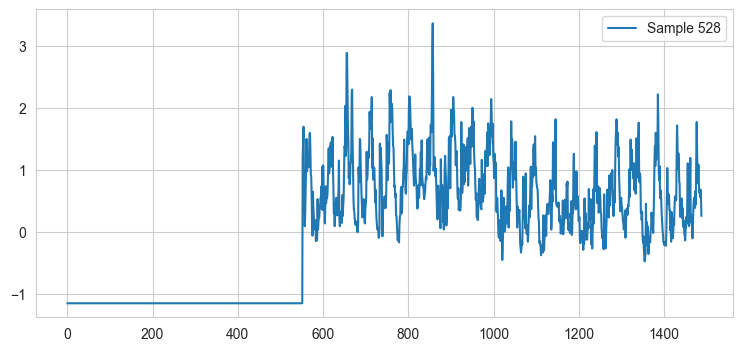

In [229]:
plot_data(528)

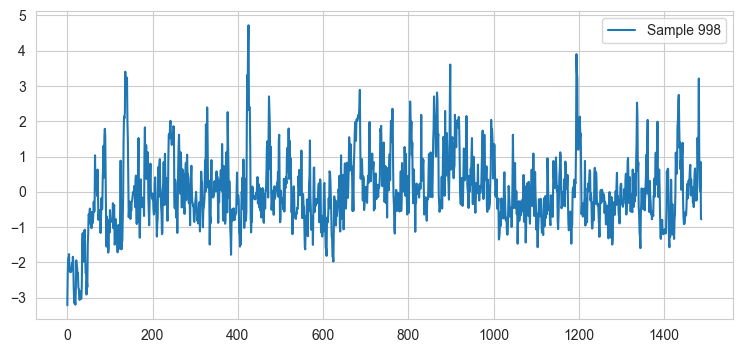

In [230]:
plot_data(998)

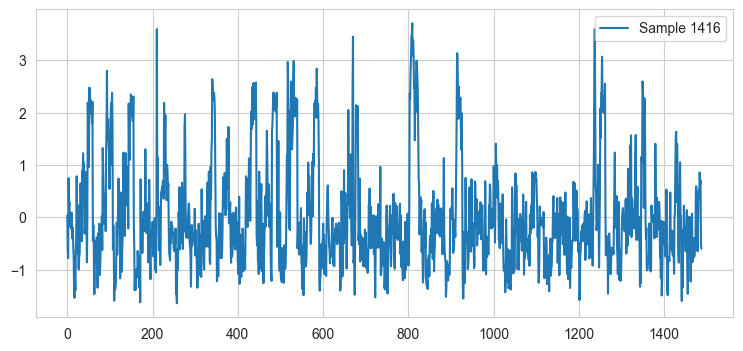

In [231]:
plot_data(1416)

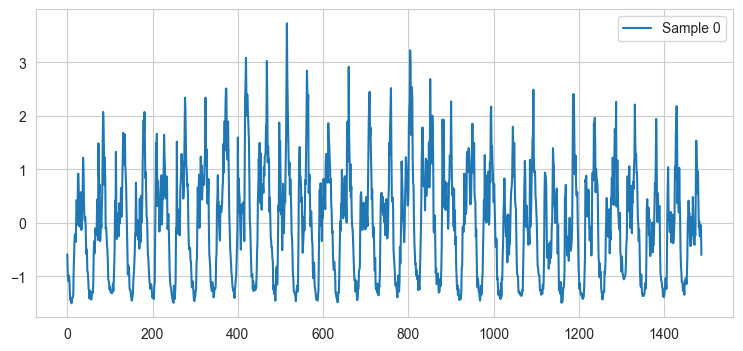

In [232]:
plot_data(0)

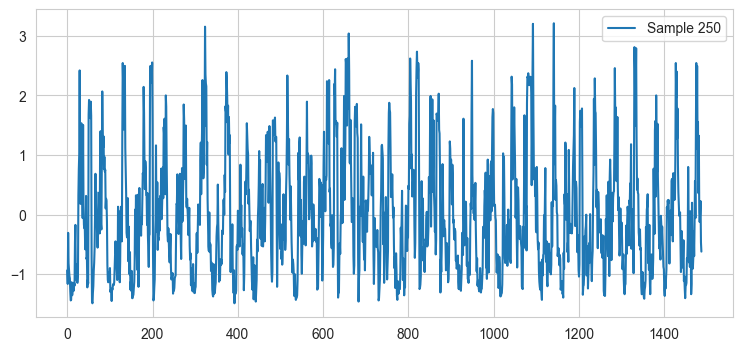

In [233]:
plot_data(250)

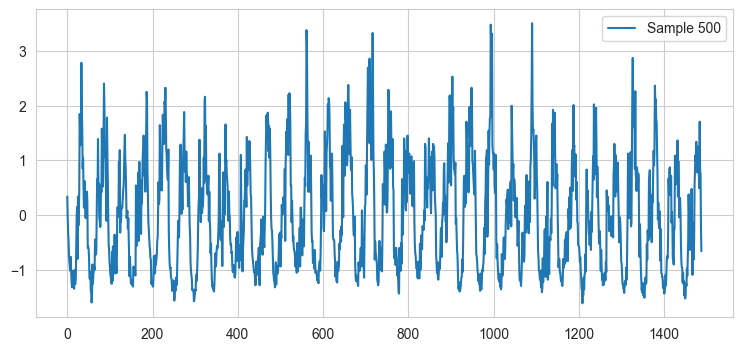

In [234]:
plot_data(500)

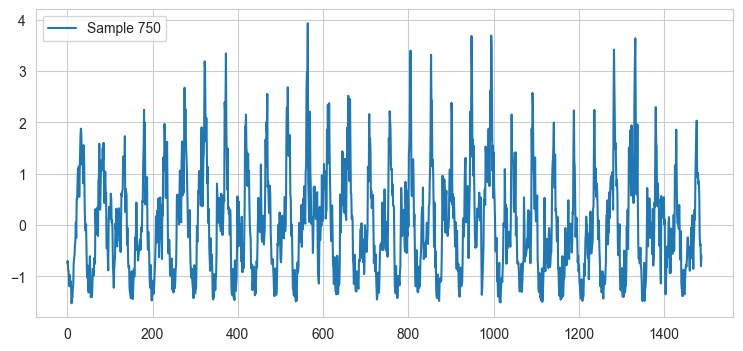

In [235]:
plot_data(750)